In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/binaryclassificationwithabankchurndataset/sample_submission.csv
/kaggle/input/competitions/binaryclassificationwithabankchurndataset/train.csv
/kaggle/input/competitions/binaryclassificationwithabankchurndataset/test.csv


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import  (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

In [31]:
input_path = '/kaggle/input/competitions/binaryclassificationwithabankchurndataset/'
train = pd.read_csv(input_path + 'train.csv')
test = pd.read_csv(input_path + 'test.csv')

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

Train: (15000, 14)
Test: (10000, 13)


In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [33]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,14999.000000,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


In [34]:
train

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.00,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.00,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.00,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.00,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.00,2.0,1.0,0.0,158958.90,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15733888.0,H?,581.0,France,Male,35.0,1.0,0.00,2.0,1.0,0.0,161653.50,0.0
14996,14996,15740164.0,Ch'in,806.0,Germany,Male,42.0,1.0,129120.64,2.0,1.0,1.0,161642.08,0.0
14997,14997,15629002.0,Shubin,620.0,France,Female,29.0,7.0,0.00,2.0,1.0,1.0,161579.85,0.0
14998,14998,15684548.0,Ch'in,622.0,Germany,Male,51.0,6.0,106070.89,3.0,1.0,0.0,136869.31,1.0


In [35]:
import os

# Papkadagi barcha fayllar
print(os.listdir(input_path))

# Submission namunasi: Exited ustunida 0/1 bormi yoki kasr sonlar (ehtimol)?
sample = pd.read_csv(input_path + 'sample_submission.csv')
sample.head()

['sample_submission.csv', 'train.csv', 'test.csv']


,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [36]:
# Necha mijoz qolgan / ketgan
print(train['Exited'].value_counts())
print(train['Exited'].value_counts(normalize=True).round(3))

print(train[['id', 'CustomerId', 'Surname']].nunique())

# id dan tashqari to'liq bir xil qatorlar bormi
print("Dublikatlar:", train.drop(columns='id').duplicated().sum())

Exited
0.0    12023
1.0     2977
Name: count, dtype: int64
Exited
0.0    0.802
1.0    0.198
Name: proportion, dtype: float64
id            15000
CustomerId     6306
Surname         758
dtype: int64
Dublikatlar: 0


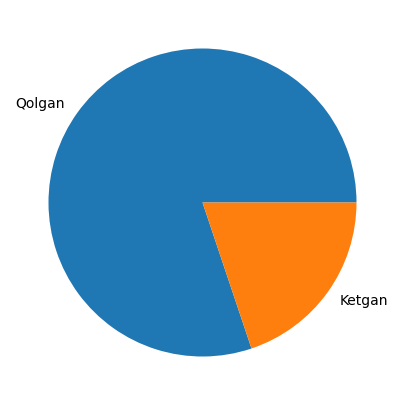

In [37]:
churn_rate = train['Exited'].value_counts()/len(train)*100
plt.figure(figsize=(5,5))
plt.pie(churn_rate, labels=['Qolgan','Ketgan'])
plt.show()

In [38]:
# Test'da bo'sh qiymat bor ustunlar
na = test.isna().sum()
print(na[na > 0])

# Kategoriya qiymatlari (imlo xatosi, ortiqcha bo'sh joy bormi)
for c in ['Geography', 'Gender']:
    print(f"--- {c} ---")
    print("train:", train[c].value_counts(dropna=False).to_dict())
    print("test: ", test[c].value_counts(dropna=False).to_dict())

Series([], dtype: int64)
--- Geography ---
train: {'France': 9040, 'Spain': 3280, 'Germany': 2680}
test:  {'France': 5979, 'Spain': 2198, 'Germany': 1823}
--- Gender ---
train: {'Male': 8478, 'Female': 6522}
test:  {'Male': 5625, 'Female': 4375}


In [39]:
# NumOfProducts taqsimoti (5 nechta?)
print(train['NumOfProducts'].value_counts().sort_index())

print(train['CreditScore'].describe())

# Age, Tenure, NumOfProducts... butun son bo'lishi kerak; kasr qiymat bormi
for c in ['Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']:
    print(f"{c:15} kasr qiymatlar: {(train[c] % 1 != 0).sum()}")

# 200k dan katta maoshlar nechta va qanday ko'rinadi
print((train['EstimatedSalary'] > 200_000).sum(), "ta qator 200k dan yuqori")
train.nlargest(10, 'EstimatedSalary')[['Age', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']]

NumOfProducts
1.0    6379
2.0    8406
3.0     194
4.0      20
5.0       1
Name: count, dtype: int64
count    15000.000000
mean       657.856800
std         72.678739
min        431.000000
25%        602.000000
50%        661.000000
75%        707.000000
max        850.000000
Name: CreditScore, dtype: float64
Age             kasr qiymatlar: 0
Tenure          kasr qiymatlar: 0
NumOfProducts   kasr qiymatlar: 0
HasCrCard       kasr qiymatlar: 0
IsActiveMember  kasr qiymatlar: 0
1 ta qator 200k dan yuqori


,Age,Balance,NumOfProducts,EstimatedSalary,Exited
6309,33.0,0.00,2.0,885120.79,0.0
11144,57.0,0.00,1.0,199953.33,1.0
10663,30.0,0.00,2.0,199808.10,0.0
7456,40.0,0.00,1.0,199805.63,1.0
2454,40.0,139972.18,1.0,199761.29,1.0
5858,43.0,0.00,1.0,199753.97,1.0
7987,41.0,145751.03,2.0,199753.97,0.0
13242,39.0,152303.80,1.0,199674.83,0.0
11459,42.0,0.00,2.0,199644.20,0.0
13465,43.0,116917.07,1.0,199644.20,0.0


In [40]:
# Kategoriya va binary ustunlar bo'yicha ketish foizi
for c in ['Geography', 'Gender', 'NumOfProducts', 'IsActiveMember', 'HasCrCard']:
    print(train.groupby(c)['Exited'].agg(['mean', 'count']).round(3), '\n')

# Balansi nol va nol emas mijozlar
print(train.groupby(train['Balance'] == 0)['Exited'].mean().round(3), '\n')

# Yosh guruhlari bo'yicha
age_bins = pd.cut(train['Age'], bins=[17, 30, 40, 50, 60, 100])
print(train.groupby(age_bins, observed=True)['Exited'].mean().round(3))

            mean  count
Geography              
France     0.154   9040
Germany    0.406   2680
Spain      0.152   3280 

         mean  count
Gender              
Female  0.276   6522
Male    0.139   8478 

                mean  count
NumOfProducts              
1.0            0.380   6379
2.0            0.042   8406
3.0            0.954    194
4.0            0.850     20
5.0            1.000      1 

                 mean  count
IsActiveMember              
0.0             0.273   7560
1.0             0.123   7440 

            mean  count
HasCrCard              
0.0        0.206   3313
1.0        0.196  11687 

Balance
False    0.288
True     0.151
Name: Exited, dtype: float64 

Age
(17, 30]     0.041
(30, 40]     0.097
(40, 50]     0.406
(50, 60]     0.720
(60, 100]    0.360
Name: Exited, dtype: float64


In [41]:
# Test'dagi NumOfProducts taqsimoti
print(test['NumOfProducts'].value_counts().sort_index())

# Test'da 200k dan katta maoshlar
print((test['EstimatedSalary'] > 200_000).sum(), "ta qator 200k dan yuqori")

# Test statistikasi — train describe() bilan solishtiring
test.describe().T

NumOfProducts
1.0    4217
2.0    5613
3.0     151
4.0      17
6.0       2
Name: count, dtype: int64
0 ta qator 200k dan yuqori


,count,mean,std,min,25%,50%,75%,max
id,10000.0,1.999950e+04,2886.895680,15000.00,17499.75,19999.50,2.249925e+04,24999.00
CustomerId,10000.0,1.569225e+07,71503.208941,15566251.00,15633629.50,15689953.50,1.575763e+07,15815660.00
CreditScore,10000.0,6.585853e+02,72.442214,431.00,602.00,663.00,7.090000e+02,850.00
Age,10000.0,3.775660e+01,8.146459,18.00,32.00,37.00,4.200000e+01,72.00
Tenure,10000.0,5.043300e+00,2.797286,0.00,3.00,5.00,7.000000e+00,10.00
Balance,10000.0,4.233682e+04,59461.091171,0.00,0.00,0.00,1.087394e+05,187841.99
NumOfProducts,10000.0,1.597600e+00,0.533763,1.00,1.00,2.00,2.000000e+00,6.00
HasCrCard,10000.0,7.793000e-01,0.414739,0.00,1.00,1.00,1.000000e+00,1.00
IsActiveMember,10000.0,4.928000e-01,0.499973,0.00,0.00,0.00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.175225e+05,46036.567342,479.54,82868.34,122612.01,1.575674e+05,199992.48


Buni tekshirishdan maqsad yuqoridagi ko'rsatkich bo'yicha balansi yoq customerlar ketishi foizi koproq chiqgan edi, quyidagi resultda korinib turibdi bu faqat Germaniya ga bog'liq ekan, qolganlarda normal

In [42]:
print(pd.crosstab(train['Geography'], train['Balance'] == 0,
                  normalize='index').round(3))

Balance    False  True 
Geography              
France     0.202  0.798
Germany    1.000  0.000
Spain      0.212  0.788


Tozalash

In [43]:
def prepare(df):
    df = df.copy()

    # 1. Identifikatorlar
    df = df.drop(columns=['id', 'CustomerId', 'Surname'])

    # 2. Butun sonl ustunlarni float'dan int'ga
    int_cols = ['Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']
    df[int_cols] = df[int_cols].astype(int)

    # 3. NumOfProducts: 3, 4, 5 — kichik va o'xshash guruhlar → bitta "3+" guruh
    df['NumOfProducts'] = df['NumOfProducts'].clip(upper=3)

    # 4. Maoshdagi bitta ekstremal qiymatni chegaralash
    df['EstimatedSalary'] = df['EstimatedSalary'].clip(upper=200_000)

    # 5. Yangi belgi: balans nolmi (Balance ikki guruhga bo'lingani uchun)
    df['Balance_zero'] = (df['Balance'] == 0).astype(int)

    # 6. Gender → 0/1 (Male = 1)
    df['Gender'] = (df['Gender'] == 'Male').astype(int)

    # 7. Geography va NumOfProducts → one-hot (NumOfProducts chiziqli emas)
    df = pd.get_dummies(df, columns=['Geography', 'NumOfProducts'],
                        drop_first=True, dtype=int)
    return df

In [44]:
# Train: target'ni ajratib olamiz
X = prepare(train.drop(columns='Exited'))
y = train['Exited'].astype(int)

# Test: id submission uchun kerak bo'ladi
X_test = prepare(test)
test_ids = test['id']

print(X.shape, X_test.shape)
print("Ustunlar bir xilmi:", list(X.columns) == list(X_test.columns))
X.head()

(15000, 13) (10000, 13)
Ustunlar bir xilmi: True


,CreditScore,Gender,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Balance_zero,Geography_Germany,Geography_Spain,NumOfProducts_2,NumOfProducts_3
0,567.0,1,33,9,0.0,1,0,156792.89,1,0,0,1,0
1,628.0,0,38,3,0.0,1,1,51987.99,1,0,0,0,0
2,635.0,0,29,3,0.0,1,1,113079.19,1,0,0,1,0
3,681.0,1,28,6,0.0,1,0,14081.64,1,0,0,1,0
4,587.0,0,27,5,0.0,1,0,158958.90,1,0,0,1,0


In [45]:
# Hamma modellar uchun bir xil 5 bo'lak
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    # LogReg ustunlar shkalasiga sezgir (Balance yuz minglarda, HasCrCard 0/1) — scaler kerak
    "LogReg": Pipeline([("scaler", StandardScaler()),
                        ("model", LogisticRegression(max_iter=1000))]),
    # Daraxt modellari — scaler shart emas
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                           random_state=42),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "HistGB": HistGradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores.mean()
    print(f"{name:13} ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

best_name = max(results, key=results.get)
print("\nEng yaxshi model:", best_name)

LogReg        ROC-AUC = 0.9206 ± 0.0039
RandomForest  ROC-AUC = 0.9310 ± 0.0028
GradBoost     ROC-AUC = 0.9329 ± 0.0033
HistGB        ROC-AUC = 0.9305 ± 0.0033

Eng yaxshi model: GradBoost


In [46]:
# Butun train'da o'qitish
final_model = models[best_name]
final_model.fit(X, y)

test_proba = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"id": test_ids, "Exited": test_proba})
submission.to_csv("/kaggle/working/submission.csv", index=False)

print(submission.shape)
print(submission["Exited"].describe().round(3))
submission.head()

(10000, 2)
count    10000.000
mean         0.200
std          0.288
min          0.003
25%          0.017
50%          0.046
75%          0.251
max          0.993
Name: Exited, dtype: float64


,id,Exited
0,15000,0.063242
1,15001,0.159466
2,15002,0.027014
3,15003,0.115549
4,15004,0.016131


In [47]:
from sklearn.model_selection import cross_val_predict

# Har bir train mijozi uchun uni ko'rmagan modeldan ehtimol
oof_proba = cross_val_predict(models[best_name], X, y, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]

# 10 ta teng guruh: model nima dedi va haqiqatda nima bo'ldi
calib = pd.DataFrame({"proba": oof_proba, "real": y.values})
calib["guruh"] = pd.qcut(calib["proba"], q=10, duplicates="drop")

print(calib.groupby("guruh", observed=True)
           .agg(model_aytgan=("proba", "mean"),
                haqiqatda=("real", "mean"),
                soni=("real", "size"))
           .round(3))

                   model_aytgan  haqiqatda  soni
guruh                                           
(0.00591, 0.0112]         0.009      0.002  1503
(0.0112, 0.0148]          0.013      0.005  1497
(0.0148, 0.02]            0.017      0.008  1502
(0.02, 0.0287]            0.024      0.025  1498
(0.0287, 0.0463]          0.036      0.033  1500
(0.0463, 0.0845]          0.063      0.051  1500
(0.0845, 0.168]           0.122      0.133  1500
(0.168, 0.37]             0.255      0.265  1500
(0.37, 0.751]             0.553      0.559  1500
(0.751, 0.993]            0.891      0.903  1500


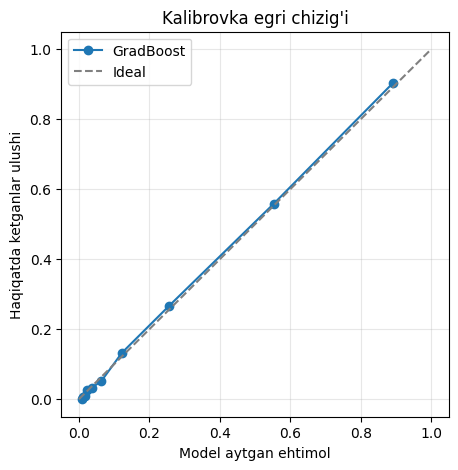

Brier:    model 0.0749 | sodda 0.1591
Log loss: model 0.2489 | sodda 0.4983


In [48]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label=best_name)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Ideal")
plt.xlabel("Model aytgan ehtimol")
plt.ylabel("Haqiqatda ketganlar ulushi")
plt.title("Kalibrovka egri chizig'i")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Sodda model: hammaga train'dagi ketish ulushini beradi
base = np.full_like(oof_proba, y.mean())
print(f"Brier:    model {brier_score_loss(y, oof_proba):.4f} | sodda {brier_score_loss(y, base):.4f}")
print(f"Log loss: model {log_loss(y, oof_proba):.4f} | sodda {log_loss(y, base):.4f}")